<img src="../../../figs/holberton_logo.png" alt="logo" width="500"/>

# Autoencoders

## 0. "Vanilla" Autoencoder

Write a function def `autoencoder(input_dims, hidden_layers, latent_dims)`: that creates an autoencoder:

- `input_dims` is an integer containing the dimensions of the model input


- `hidden_layers` is a list containing the number of nodes for each hidden layer in the encoder, respectively


- the hidden layers should be reversed for the decoder


- `latent_dims` is an integer containing the dimensions of the latent space representation


- Returns: `encoder, decoder, auto`
    - `encoder` is the encoder model
    - `decoder` is the decoder model
    - `auto` is the full autoencoder model


The autoencoder model should be compiled using `adam` optimization and binary `cross-entropy` loss. 
All layers should use a `relu` activation except for the last layer in the decoder, which should use `sigmoid`


### Key Points


#### Encoder 

The goal of the **encoder** is to **transform the high-dimensional input data into a lower-dimensional latent space representation**. 


It does so by employing a series of **dense layers with ReLU activation functions, extracting and encoding essential features and patterns from the input data**. 


The encoder's **final layer**, with latent_dims units and ReLU activation, **acts as the bottleneck layer**, capturing a compressed representation of the data that retains its most critical information.


#### Decoder

The goal of the  **decoder is to reverse the encoding process, taking the compressed latent space representation and reconstructing it back into the original data space**. 


It accomplishes this by using dense layers with ReLU activation functions, **mirroring the architecture of the encoder in reverse order**. 


The decoder's final layer employs a sigmoid activation function to produce output values in the range `[0, 1]`, facilitating the reconstruction of the input data.



#### Latent Space

The latent space is the **central concept of an autoencoder, representing a lower-dimensional, compressed representation of the input data**. 


The essence of the latent space idea is to capture the most salient and essential features of the input data while discarding less relevant information. This compressed representation serves as a bottleneck or bottleneck layer within the network, enabling efficient feature extraction and dimensionality reduction. 


In [1]:
#!/usr/bin/env python3
"""Vanilla Autoencoder Module"""
import tensorflow.keras as keras


def autoencoder(input_dim, hidden_layers, latent_dim):
    
    """Creates an autoencoder """
    
    encoder_input = keras.layers.Input(shape=(input_dim,))
    encoder_output = encoder_input
    
    for units in hidden_layers:
        encoder_output = keras.layers.Dense(
            units, activation='relu')(encoder_output)

    latent_space = keras.layers.Dense(
        latent_dim, activation='relu')(encoder_output)
    encoder = keras.models.Model(encoder_input, latent_space)

    decoder_input = keras.layers.Input(shape=(latent_dim,))
    decoder_output = decoder_input
    for units in reversed(hidden_layers):
        decoder_output = keras.layers.Dense(
            units, activation='relu')(decoder_output)

    decoder_output = keras.layers.Dense(
        input_dim, activation='sigmoid')(decoder_output)
    decoder = keras.models.Model(decoder_input, decoder_output)

    auto_outputs = encoder(encoder_input)
    auto_outputs = decoder(auto_outputs)
    autoencoder = keras.models.Model(encoder_input, auto_outputs)
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

    return encoder, decoder, autoencoder


### Main (Test) File

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - loss: 0.4524 - val_loss: 0.3194
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.3132 - val_loss: 0.3074
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.3033 - val_loss: 0.3018
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.2983 - val_loss: 0.2979
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.2950 - val_loss: 0.2963
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
4.5764966
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


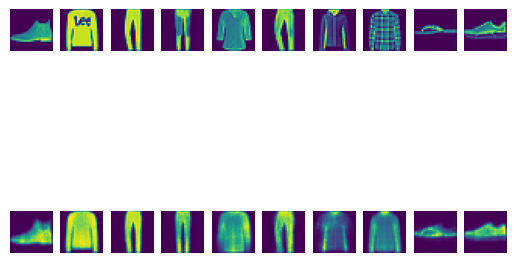

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.datasets import fashion_mnist


autoencoder = autoencoder

# (x_train, _), (x_test, _) = mnist.load_data()
(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((-1, 784))
x_test = x_test.reshape((-1, 784))
np.random.seed(0)
tf.random.set_seed(0)
encoder, decoder, auto = autoencoder(784, [128, 64], 32)
auto.fit(x_train, x_train, epochs=5, batch_size=256, shuffle=True,
                validation_data=(x_test, x_test))
encoded = encoder.predict(x_test[:10])
print(np.mean(encoded))
reconstructed = decoder.predict(encoded)

for i in range(10):
    ax = plt.subplot(2, 10, i + 1)
    ax.axis('off')
    plt.imshow(x_test[i].reshape((28, 28)))
    ax = plt.subplot(2, 10, i + 11)
    ax.axis('off')
    plt.imshow(reconstructed[i].reshape((28, 28)))
plt.show()

### Test with Cifar - 10 Dataset

In this test, we evaluate the performance of a vanilla autoencoder on the CIFAR-10 dataset. CIFAR-10 images are 32x32 RGB, so the input size is adjusted to 3072 pixels. The autoencoder is trained to compress and reconstruct these images, and we visualize the original and reconstructed images to assess how well the model performs. This test helps us observe the quality of reconstruction on more complex, colored image data compared to grayscale datasets like MNIST.


Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 37s 166ms/step - loss: 0.6562 - val_loss: 0.6075
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 37s 141ms/step - loss: 0.6069 - val_loss: 0.5981
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 30s 152ms/step - loss: 0.5956 - val_loss: 0.5934
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - loss: 0.5904 - val_loss: 0.5889
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step - loss: 0.5880 - val_loss: 0.5868
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - loss: 0.5857 - val_loss: 0.5844
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - loss: 0.5838 - val_loss: 0.5856
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - loss: 0.5826 - val_loss: 0.5828
Epoch 9/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 15s 76ms/step - loss: 0.5810 - val_loss: 0.5811
Epoch 10/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 15s 76ms/step - loss: 0.5803 - val_loss: 0.5826
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
0.63589174
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


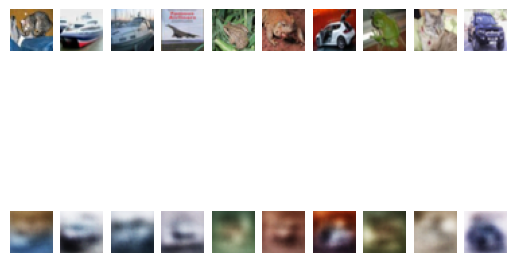

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

(x_train, _), (x_test, _) = cifar10.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((-1, 32 * 32 * 3))
x_test = x_test.reshape((-1, 32 * 32 * 3))

np.random.seed(0)
tf.random.set_seed(0)

# Build the autoencoder with the appropriate input size (32*32*3 = 3072)
encoder, decoder, auto = autoencoder(3072, [512, 256], 128)

auto.fit(x_train, x_train, epochs=10, batch_size=256, shuffle=True,
         validation_data=(x_test, x_test))

encoded = encoder.predict(x_test[:10])

print(np.mean(encoded))

reconstructed = decoder.predict(encoded)

# Plot original vs reconstructed images
for i in range(10):
    ax = plt.subplot(2, 10, i + 1)
    ax.axis('off')
    plt.imshow(x_test[i].reshape((32, 32, 3)))  # Original image

    ax = plt.subplot(2, 10, i + 11)
    ax.axis('off')
    plt.imshow(reconstructed[i].reshape((32, 32, 3)))  # Reconstructed image

plt.show()


## 1. Sparse Autoencoder

Write a function `def autoencoder(input_dims, hidden_layers, latent_dims, lambtha)`: that creates a sparse autoencoder:

- `input_dims` is an integer containing the dimensions of the model input


- `hidden_layers` is a list containing the number of nodes for each hidden layer in the encoder, respectively


- the hidden layers should be reversed for the decoder


- `latent_dims` is an integer containing the dimensions of the latent space representation


- `lambtha` is the regularization parameter used for L1 regularization on the encoded output


- Returns: `encoder, decoder, auto`
    - `encoder` is the encoder model
    - `decoder` is the decoder model
    - `auto` is the sparse autoencoder model


The sparse autoencoder model should be compiled using adam optimization and binary cross-entropy loss


All layers should use a `relu` activation except for the last layer in the decoder, which should use sigmoid


### Key Points

#### Sparse Autoencoders

A **sparse autoencoder** is a type of neural network architecture designed to learn sparse representations of input data. Its goal is to **find a compact and informative representation of the input data while minimizing the number of active (non-zero) neurons in the hidden layers**. 


By introducing sparsity constraints, such as L1 regularization, the network aims to **force many neurons to remain inactive, resulting in a sparse code**. It emphasizes the most relevant and discriminative features of the input data while reducing noise and redundancy.


#### Implementation

In this sparse autoencoder implementation, the key change is the addition of `L1` regularization to the encoder's output layer (`encoder_outputs`). This encourages sparsity in the learned representations. 


The regularization term is controlled by the `lambtha` parameter, which determines the strength of `L1` regularization. 


The rest of the architecture, including activation functions and the use of the sigmoid activation in the decoder's last layer, remains the same as the vanilla autoencoder.

In [12]:
#!/usr/bin/env python3
"""Vanilla Autoencoder Module"""
import tensorflow.keras as keras


def autoencoder(input_dims, hidden_layers, latent_dims, lambtha):
    
    """Creates a sparse autoencoder """
    
    encoder_input = keras.layers.Input(shape=(input_dims,))
    encoder_output = encoder_input
    
    for units in hidden_layers:
        encoder_output = keras.layers.Dense(
            units, activation='relu')(encoder_output)

    latent_space = keras.layers.Dense(
        latent_dims, activation='relu',
        activity_regularizer=keras.regularizers.l1(lambtha))(encoder_output)
    encoder = keras.models.Model(encoder_input, latent_space)

    decoder_input = keras.layers.Input(shape=(latent_dims,))
    decoder_output = decoder_input
    for units in reversed(hidden_layers):
        decoder_output = keras.layers.Dense(
            units, activation='relu')(decoder_output)

    decoder_output = keras.layers.Dense(
        input_dims, activation='sigmoid')(decoder_output)
    decoder = keras.models.Model(decoder_input, decoder_output)

    auto_outputs = encoder(encoder_input)
    auto_outputs = decoder(auto_outputs)
    autoencoder = keras.models.Model(encoder_input, auto_outputs)
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

    return encoder, decoder, autoencoder


### Test (Main) File

Epoch 1/35
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.3879 - val_loss: 0.2399
Epoch 2/35
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2300 - val_loss: 0.2048
Epoch 3/35
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1998 - val_loss: 0.1859
Epoch 4/35
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1828 - val_loss: 0.1683
Epoch 5/35
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1675 - val_loss: 0.1609
Epoch 6/35
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1614 - val_loss: 0.1574
Epoch 7/35
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1579 - val_loss: 0.1546
Epoch 8/35
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1552 - val_loss: 0.1522
Epoch 9/35
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1531 - val_loss: 0.1502
Epoch 10/35
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1511 - val_loss: 0.1485
Epoch 11/35
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1494 - val_loss: 0.1469
Epoch 12/35
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s

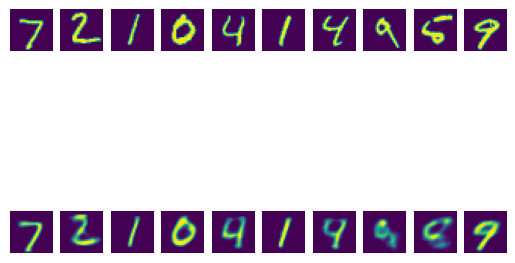

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist

autoencoder = autoencoder

(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((-1, 784))
x_test = x_test.reshape((-1, 784))
np.random.seed(0)
tf.random.set_seed(0)

encoder, decoder, auto = autoencoder(784, [128, 64], 32, 10e-6)
auto.fit(x_train, x_train, epochs=35,batch_size=256, shuffle=True,
                validation_data=(x_test, x_test))
encoded = encoder.predict(x_test[:10])
print(np.mean(encoded))
reconstructed = decoder.predict(encoded)

for i in range(10):
    ax = plt.subplot(2, 10, i + 1)
    ax.axis('off')
    plt.imshow(x_test[i].reshape((28, 28)))
    ax = plt.subplot(2, 10, i + 11)
    ax.axis('off')
    plt.imshow(reconstructed[i].reshape((28, 28)))

## 2. Convolutional Autoencoder

Write a function `def autoencoder(input_dims, filters, latent_dims)`: that creates a convolutional autoencoder:

- `input_dims` is a tuple of integers containing the dimensions of the model input


- `filters` is a list containing the number of filters for each convolutional layer in the encoder, respectively


- the filters should be reversed for the decoder


- `latent_dims` is a tuple of integers containing the dimensions of the latent space representation


- Each convolution in the encoder should use a kernel size of `(3, 3)` with `same` padding and `relu` activation, followed by `max pooling` of size `(2, 2)`


- Each convolution in the decoder, except for the last two, should use a filter size of `(3, 3)` with same padding and relu activation, followed by upsampling of size `(2, 2)`



- The second to last convolution should instead use `valid` padding



- The last convolution should have the same number of filters as the number of channels in input_dims with sigmoid activation and no upsampling



- Returns: `encoder, decoder, auto`
    - `encoder` is the encoder model
    - `decoder` is the decoder model
    - `auto` is the full autoencoder model


The autoencoder model should be compiled using `adam` optimization and binary `cross-entropy` loss

In [20]:
#!/usr/bin/env python3
"""Convolutional Autoencoder Module"""
import tensorflow.keras as keras


def autoencoder(input_dims, filters, latent_dims):
    """Creates a convolutional autoencoder """
    encoder_input = keras.layers.Input(shape=input_dims)
    encoder_output = encoder_input
    for f in filters:
        encoder_output = keras.layers.Conv2D(
            f, (3, 3), padding='same', activation='relu')(encoder_output)
        encoder_output = keras.layers.MaxPooling2D(
            (2, 2), padding='same')(encoder_output)

    encoder = keras.models.Model(encoder_input, encoder_output)

    decoder_input = keras.layers.Input(shape=latent_dims)
    decoder_output = decoder_input
    for f in reversed(filters[1:]):
        decoder_output = keras.layers.Conv2D(
            f, (3, 3), padding='same', activation='relu')(decoder_output)
        decoder_output = keras.layers.UpSampling2D((2, 2))(decoder_output)

    decoder_output = keras.layers.Conv2D(
        filters[0], (3, 3), activation='relu')(decoder_output)
    decoder_output = keras.layers.UpSampling2D((2, 2))(decoder_output)
    decoder_output = keras.layers.Conv2D(
        input_dims[-1], (3, 3), padding='same',
        activation='sigmoid')(decoder_output)
    decoder = keras.models.Model(decoder_input, decoder_output)

    auto_outputs = encoder(encoder_input)
    auto_outputs = decoder(auto_outputs)
    autoencoder = keras.models.Model(encoder_input, auto_outputs)
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

    return encoder, decoder, autoencoder


### Main (Test) File

(60000, 28, 28, 1)
(10000, 28, 28, 1)
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - loss: 0.3612 - val_loss: 0.1636
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.1565 - val_loss: 0.1383
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - loss: 0.1368 - val_loss: 0.1285
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.1282 - val_loss: 0.1227
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.1227 - val_loss: 0.1180
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 0.1182 - val_loss: 0.1144
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - loss: 0.1148 - val_loss: 0.1115
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - loss: 0.1121 - val_loss: 0.1092
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - loss: 0.1100 - val_loss: 0.1073
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - loss: 0.1082 - val_loss: 0.1056
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
3.241537
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step


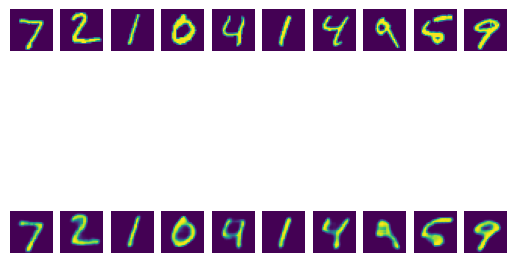

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist

autoencoder = autoencoder

(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.expand_dims(x_train, axis=3)
x_test = np.expand_dims(x_test, axis=3)
print(x_train.shape)
print(x_test.shape)
np.random.seed(0)
tf.random.set_seed(0)
encoder, decoder, auto = autoencoder((28, 28, 1), [16, 8, 8], (4, 4, 8))
auto.fit(x_train, x_train, epochs=10, batch_size=256, shuffle=True,
                validation_data=(x_test, x_test))
encoded = encoder.predict(x_test[:10])
print(np.mean(encoded))
reconstructed = decoder.predict(encoded)[:,:,:,0]

for i in range(10):
    ax = plt.subplot(2, 10, i + 1)
    ax.axis('off')
    plt.imshow(x_test[i,:,:,0])
    ax = plt.subplot(2, 10, i + 11)
    ax.axis('off')
    plt.imshow(reconstructed[i])
plt.show()

### Test with Cifar - 10

In [29]:
#!/usr/bin/env python3
"""Convolutional Autoencoder Module"""
import tensorflow.keras as keras


def autoencoder(input_dims, filters, latent_dims):
    """Creates a convolutional autoencoder """
    # Encoder
    encoder_input = keras.layers.Input(shape=input_dims)
    encoder_output = encoder_input
    for f in filters:
        encoder_output = keras.layers.Conv2D(
            f, (3, 3), padding='same', activation='relu')(encoder_output)
        encoder_output = keras.layers.MaxPooling2D(
            (2, 2), padding='same')(encoder_output)

    encoder = keras.models.Model(encoder_input, encoder_output)

    # Decoder
    decoder_input = keras.layers.Input(shape=latent_dims)
    decoder_output = decoder_input
    for f in reversed(filters):
        decoder_output = keras.layers.Conv2D(
            f, (3, 3), padding='same', activation='relu')(decoder_output)
        decoder_output = keras.layers.UpSampling2D((2, 2))(decoder_output)

    # Final layer to restore the original image dimensions (32x32x3)
    decoder_output = keras.layers.Conv2D(
        input_dims[-1], (3, 3), padding='same', activation='sigmoid')(decoder_output)

    decoder = keras.models.Model(decoder_input, decoder_output)

    # Full autoencoder model
    auto_outputs = encoder(encoder_input)
    auto_outputs = decoder(auto_outputs)
    autoencoder = keras.models.Model(encoder_input, auto_outputs)

    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

    return encoder, decoder, autoencoder


Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 62s 281ms/step - loss: 0.6475 - val_loss: 0.5994
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 53s 272ms/step - loss: 0.5948 - val_loss: 0.5895
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 81s 268ms/step - loss: 0.5878 - val_loss: 0.5865
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 56s 285ms/step - loss: 0.5851 - val_loss: 0.5846
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 77s 258ms/step - loss: 0.5835 - val_loss: 0.5836
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 92s 310ms/step - loss: 0.5824 - val_loss: 0.5827
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 75s 274ms/step - loss: 0.5817 - val_loss: 0.5823
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 54s 275ms/step - loss: 0.5810 - val_loss: 0.5819
Epoch 9/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 84s 283ms/step - loss: 0.5806 - val_loss: 0.5812
Epoch 10/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 81s 278ms/step - loss: 0.5801 - val_loss: 0.5808
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
0.52327174
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 661ms/step


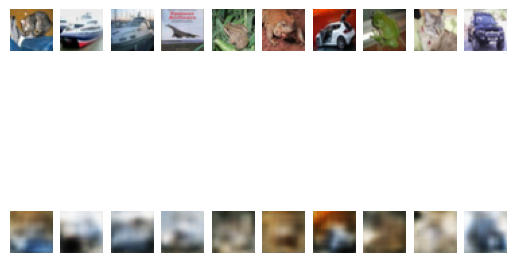

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

(x_train, _), (x_test, _) = cifar10.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# CIFAR-10 images are already 32x32x3, so no need for reshaping

# Set random seeds for reproducibility
np.random.seed(0)
tf.random.set_seed(0)

# Build the convolutional autoencoder for CIFAR-10
encoder, decoder, auto = autoencoder((32, 32, 3), [32, 16, 8], (4, 4, 8))

# Train the autoencoder
auto.fit(x_train, x_train, epochs=10, batch_size=256, shuffle=True,
         validation_data=(x_test, x_test))

# Use the encoder to encode the test images
encoded = encoder.predict(x_test[:10])

# Print the mean of the encoded representations for inspection
print(np.mean(encoded))

# Use the decoder to reconstruct the encoded representations
reconstructed = decoder.predict(encoded)

# Plot original vs reconstructed images
for i in range(10):
    ax = plt.subplot(2, 10, i + 1)
    ax.axis('off')
    plt.imshow(x_test[i])  # Original CIFAR-10 image

    ax = plt.subplot(2, 10, i + 11)
    ax.axis('off')
    plt.imshow(reconstructed[i])  # Reconstructed CIFAR-10 image

plt.show()
